# Add all required library
## y = 13*xs + 7 *zs -12


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [54]:
# declare variable containing size of training set
observations = 10000

# Create xs and zs of 1000x1 matrix
xs = np.random.uniform(low=-10, high=10, size=(observations, 1))
zs = np.random.uniform(low=-10, high=10, size=(observations, 1))

# Combine xs,zs into single matrix with size of 1000x2
# This is the X matrix from liner model y=X*w + b
## column_stack
inputs = np.column_stack((xs, zs))
print(f"X shape = {inputs.shape}")


X shape = (10000, 2)


# Generating target that we are aiming at

In [55]:
# We want to "make up" a function, use the ML methodology, and see if the algorithm has learned it.
# We add a small random noise to the function i.e. f(x,z) = 2x - 3z + 5 + <small noise>
noise = np.random.uniform(low=-1, high=1, size=(observations, 1))
print(f"Noise shape = {noise.shape}")
# Produce the targets according to the f(x,z) = 2x - 3z + 5 + noise definition.
# In this way, we are basically saying: the weights should be 2 and -3, while the bias is
targets = 13 * xs + 7 * zs - 12 + noise
print(f"Target shape = {targets.shape}")

Noise shape = (10000, 1)
Target shape = (10000, 1)


# Plot training data

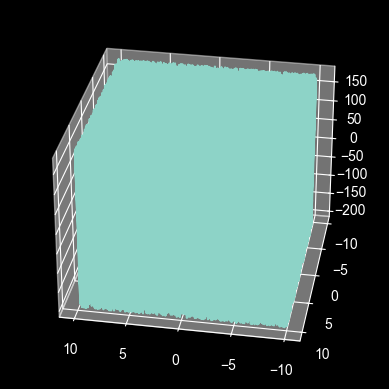

In [56]:
# In order to use the 3D plot, the objects should have a certain shape, so we reshape the targets.
# The proper method to use is reshape and takes as arguments the dimensions in which we want to fit the object.
targets = targets.reshape(observations,)
# Plotting according to the conventional matplotlib.pyplot syntax

# Declare the figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# Choose the area
ax.plot(xs,zs, targets)

# You can fiddle with the azim parameter to plot the data from different angles. Just change the value of azim=100
# to azim = 0 ; azim = 200, or whatever. Check and see what happens.
ax.view_init(azim=100)

# So far we were just describing the plot. This method actually shows the plot.
plt.show()

# We reshape the targets back to the shape that they were in before plotting.
# This reshaping is a side-effect of the 3D plot. Sorry for that.
targets = targets.reshape(observations, 1)


# Initialize variable

In [57]:
# We will initialize the weights and biases randomly in some small initial range.
# init_range is the variable that will measure that.
# You can play around with the initial range, but we don't really encourage you to do so.
# High initial ranges may prevent the machine learning algorithm from learning.
init_range = 0.1

# Weights are of size k x m, where k is the number of input variables and m is the number of output variables
# In our case, the weights matrix is 2x1 since there are 2 inputs (x and z) and one output (y)
weights = np.random.uniform(low=-init_range, high=init_range, size=(2, 1))
# Biases are of size 1 since there is only 1 output. The bias is a scalar.
biases = np.random.uniform(low=-init_range, high=init_range, size= 1)
#Print the weights to get a sense of how they were initialized.
print(weights)
print(biases)

[[ 0.03257166]
 [-0.0315954 ]]
[-0.07966621]


# Set learning rate

In [58]:
learning_rate = 0.02

# Train model

In [59]:
# We iterate over our training dataset 100 times. That works well with a learning rate of 0.02.
# The proper number of iterations is something we will talk about later on, but generally
# a lower learning rate would need more iterations, while a higher learning rate would need less iterations
# keep in mind that a high learning rate may cause the loss to diverge to infinity, instead of converge to 0.
for i in range(100):
    # This is the linear model: y = xw + b equation
    outputs = np.dot(inputs, weights) + biases
    # The deltas are the differences between the outputs and the targets
    # Note that deltas here is a vector 1000 x 1
    deltas = outputs - targets
     # We are considering the L2-norm loss, but divided by 2, so it is consistent with the lectures.
    # Moreover, we further divide it by the number of observations.
    # This is simple rescaling by a constant. We explained that this doesn't change the optimization logic,
    # as any function holding the basic property of being lower for better results, and higher for worse results
    # can be a loss function.
    lose = np.sum(deltas**2)/2/observations
    # We print the loss function value at each step so we can observe whether it is decreasing as desired.
    print(lose)
    # Another small trick is to scale the deltas the same way as the loss function
    # In this way our learning rate is independent of the number of samples (observations).
    # Again, this doesn't change anything in principle, it simply makes it easier to pick a single learning rate
    # that can remain the same if we change the number of training samples (observations).
    # You can try solving the problem without rescaling to see how that works for you.
    deltas_scaled = deltas / observations
    # Finally, we must apply the gradient descent update rules from the relevant lecture.
    # The weights are 2x1, learning rate is 1x1 (scalar), inputs are 1000x2, and deltas_scaled are 1000x1
    # We must transpose the inputs so that we get an allowed operation.
    weights = weights - learning_rate * np.dot(inputs.T, deltas_scaled)
    biases  = biases -learning_rate * np.sum(deltas_scaled)
     # The weights are updated in a linear algebraic way (a matrix minus another matrix)
    # The biases, however, are just a single number here, so we must transform the deltas into a scalar.
    # The two lines are both consistent with the gradient descent methodology.


3680.03197213701
476.7631961328272
111.94805357162447
68.36351497599483
61.22857760283661
58.30812417140638
55.94875008819994
53.733289633173854
51.61128497539352
49.57396054505776
47.61738739275597
45.73830246212866
43.933629820594206
42.200421915902275
40.535848664890324
38.93719213989705
37.401842052228325
35.92729148112966
34.51113277946672
33.15105364240198
31.84483333184857
30.590339050446307
29.38552245912851
28.228416332592815
27.11713134721419
26.049852996156375
25.024838626643742
24.04041459455685
23.094973531705268
22.186971721315647
21.314926577450034
20.477414224238704
19.673067170974562
18.900572079273594
18.158667618655006
17.44614240703999
16.761833032806432
16.104622155169533
15.473436679787076
14.867246006610355
14.285060347119742
13.72592910819726
13.188939339997724
12.673214245283475
12.177911747789329
11.702223117279956
11.245371649054619
10.806611395743209
10.385225949322919
9.980527271366809
9.591854569614148
9.218573219028407
8.860073725581136
8.515770731069704


# Print weights and biases and see if we have worked correctly.

In [60]:
print(weights)
print(biases)

[[13.000641  ]
 [ 6.99921607]]
[-10.41735492]


# plot input and target

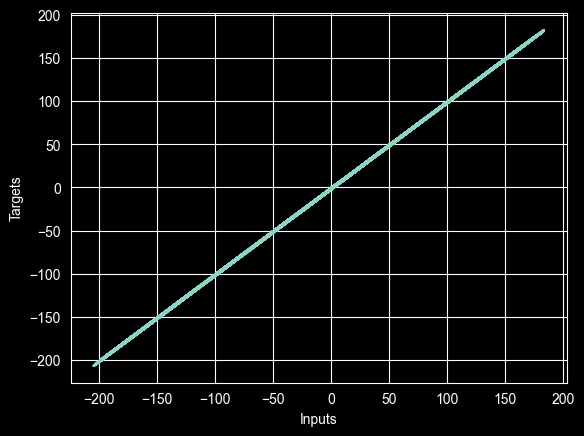

In [61]:
plt.plot(outputs, targets)
plt.xlabel("Inputs")
plt.ylabel("Targets")
plt.show()